## ML Assessment

#### Importing Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel("for_assign.xlsx")
df.head(5)

,device_timestamp,voltage,current
0,1719081007071,240,0.03
1,1719081007071,246,0.04
2,1719081007071,249,0.03
3,1719081007071,249,0.03
4,1719081007071,248,0.03


In [3]:
df.tail(5)

,device_timestamp,voltage,current
5570,1719167296519,254,10.97
5571,1719167296519,240,11.10
5572,1719167296519,247,11.08
5573,1719167296519,249,10.01
5574,1719167296519,240,9.87


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5575 entries, 0 to 5574
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   device_timestamp  5575 non-null   int64  
 1   voltage           5575 non-null   int64  
 2   current           5575 non-null   float64
dtypes: float64(1), int64(2)
memory usage: 130.8 KB


#### Looking for any null values in the dataset

In [5]:
df.isnull().sum()

device_timestamp    0
voltage             0
current             0
dtype: int64

#### Statistical summury of dataset

In [6]:
df.describe()

,device_timestamp,voltage,current
count,5.575000e+03,5575.000000,5575.000000
mean,1.719124e+12,246.992646,1.782165
std,2.516600e+07,12.457468,3.807711
min,1.719081e+12,0.000000,0.000000
25%,1.719102e+12,240.000000,0.040000
50%,1.719123e+12,249.000000,0.090000
75%,1.719146e+12,250.000000,0.360000
max,1.719167e+12,274.000000,25.400000


#### The `device_timestamp` column looking like unix timestamp so we can convert it into Human time

In [7]:
df['time'] = pd.to_datetime(df['device_timestamp'], unit='ms')
print(df.head())

   device_timestamp  voltage  current                    time
0     1719081007071      240     0.03 2024-06-22 18:30:07.071
1     1719081007071      246     0.04 2024-06-22 18:30:07.071
2     1719081007071      249     0.03 2024-06-22 18:30:07.071
3     1719081007071      249     0.03 2024-06-22 18:30:07.071
4     1719081007071      248     0.03 2024-06-22 18:30:07.071


#### Calculating Power
- Power (Watts) = Voltage x Current

In [8]:
df['power'] = df['voltage'] * df['current']
df.head()

,device_timestamp,voltage,current,time,power
0,1719081007071,240,0.03,2024-06-22 18:30:07.071,7.20
1,1719081007071,246,0.04,2024-06-22 18:30:07.071,9.84
2,1719081007071,249,0.03,2024-06-22 18:30:07.071,7.47
3,1719081007071,249,0.03,2024-06-22 18:30:07.071,7.47
4,1719081007071,248,0.03,2024-06-22 18:30:07.071,7.44


In [12]:
df.tail(10)

,device_timestamp,voltage,current,time,power
5565,1719167176517,249,10.20,2024-06-23 18:26:16.517,2539.80
5566,1719167176517,240,10.82,2024-06-23 18:26:16.517,2596.80
5567,1719167296519,249,10.14,2024-06-23 18:28:16.519,2524.86
5568,1719167296519,249,10.80,2024-06-23 18:28:16.519,2689.20
5569,1719167296519,249,11.07,2024-06-23 18:28:16.519,2756.43
5570,1719167296519,254,10.97,2024-06-23 18:28:16.519,2786.38
5571,1719167296519,240,11.10,2024-06-23 18:28:16.519,2664.00
5572,1719167296519,247,11.08,2024-06-23 18:28:16.519,2736.76
5573,1719167296519,249,10.01,2024-06-23 18:28:16.519,2492.49
5574,1719167296519,240,9.87,2024-06-23 18:28:16.519,2368.80


In [10]:
df.describe()

,device_timestamp,voltage,current,time,power
count,5.575000e+03,5575.000000,5575.000000,5575,5575.000000
mean,1.719124e+12,246.992646,1.782165,2024-06-23 06:24:38.985322240,441.922210
min,1.719081e+12,0.000000,0.000000,2024-06-22 18:30:07.071000,0.000000
25%,1.719102e+12,240.000000,0.040000,2024-06-23 00:21:09.430500096,9.920000
50%,1.719123e+12,249.000000,0.090000,2024-06-23 06:12:11.792999936,22.410000
75%,1.719146e+12,250.000000,0.360000,2024-06-23 12:38:14.321999872,87.150000
max,1.719167e+12,274.000000,25.400000,2024-06-23 18:28:16.519000,6654.800000
std,2.516600e+07,12.457468,3.807711,NaN,947.353257


#### Plot current over time

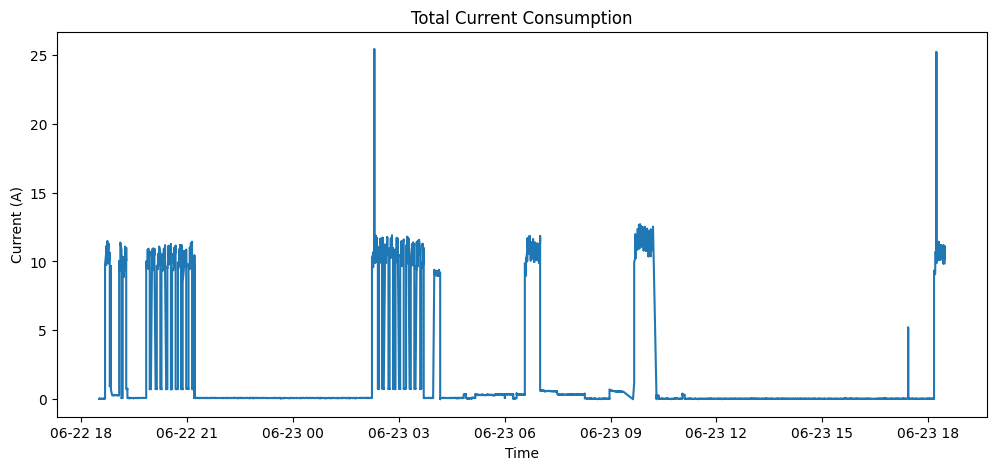

In [11]:
plt.figure(figsize=(12,5))
plt.plot(df['time'], df['current'])
plt.xlabel('Time')
plt.ylabel('Current (A)')
plt.title("Total Current Consumption")
plt.show()

- Above figure shows from 22-06-2024 18:00 i.e 06:00 to 23-06-2024 18:00 i.e 06:00


#### Histogram for see clusters of current values.

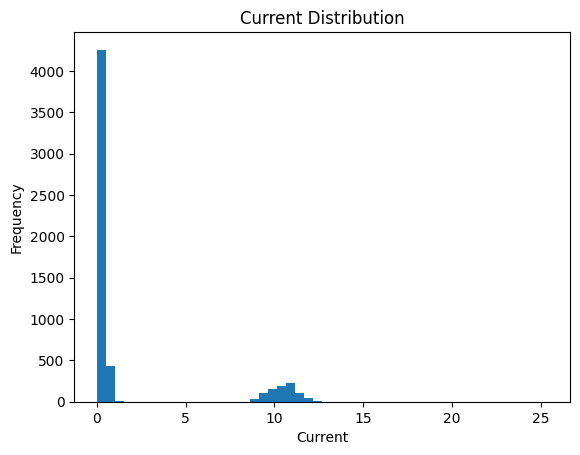

In [13]:
plt.hist(df['current'], bins=50)
plt.xlabel("Current")
plt.ylabel("Frequency")
plt.title("Current Distribution")
plt.show()

In [16]:
df['current'].describe()

count    5575.000000
mean        1.782165
std         3.807711
min         0.000000
25%         0.040000
50%         0.090000
75%         0.360000
max        25.400000
Name: current, dtype: float64

In [23]:
thr = df['current'].mean() + df['current'].std()
thr

5.589876024174462

- Statistical analysis of the dataset shows that 75% of current readings lie below 0.36 A, representing the base electrical load from small appliances such as lights and fans. However, the dataset contains occasional spikes reaching up to 25 A, indicating the presence of high power appliances.

- Using the statistical rule of mean plus standard deviation (1.78 + 3.80 ≈ 5.58 A), a threshold around 5 A was selected to identify high consumption events. 

- When the current exceeds this threshold for a sustained duration, it likely corresponds to Air Conditioner operation. This threshold-based segmentation approach helps isolate AC usage from the combined electrical signal.

If current > 5A

--> possible AC usage

In [30]:
threshold = 5

df['ac_detected'] = df['current'] > threshold
df.head(5)

,device_timestamp,voltage,current,time,power,ac_detected
0,1719081007071,240,0.03,2024-06-22 18:30:07.071,7.20,False
1,1719081007071,246,0.04,2024-06-22 18:30:07.071,9.84,False
2,1719081007071,249,0.03,2024-06-22 18:30:07.071,7.47,False
3,1719081007071,249,0.03,2024-06-22 18:30:07.071,7.47,False
4,1719081007071,248,0.03,2024-06-22 18:30:07.071,7.44,False


In [31]:
df.tail(5)

,device_timestamp,voltage,current,time,power,ac_detected
5570,1719167296519,254,10.97,2024-06-23 18:28:16.519,2786.38,True
5571,1719167296519,240,11.10,2024-06-23 18:28:16.519,2664.00,True
5572,1719167296519,247,11.08,2024-06-23 18:28:16.519,2736.76,True
5573,1719167296519,249,10.01,2024-06-23 18:28:16.519,2492.49,True
5574,1719167296519,240,9.87,2024-06-23 18:28:16.519,2368.80,True


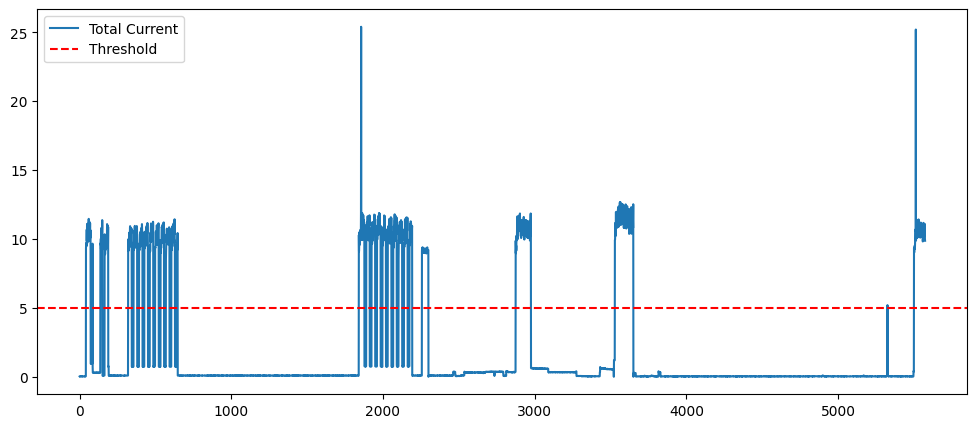

In [32]:
plt.figure(figsize=(12,5))
plt.plot(df['current'], label="Total Current")
plt.axhline(5, color='red', linestyle='--', label="Threshold")
plt.legend()
plt.show()

- This visually shows AC spikes above threshold red dotted line.

### Conclusion:
- By carefully exploring the current readings, it became clear that most of the time the room consumes only a small amount of electricity, while a few moments show strong spikes that signal heavy appliances turning on. 
- Using a simple statistical threshold and observing how long the current stays high helps us logically identify when the air conditioner is likely running. 
